In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import source

In [76]:
importlib.reload(source)

<module 'source' from 'c:\\Users\\HP\\Documents\\Keng\\Projects\\MyProject\\RealProject\\something\\source.py'>

In [77]:
from source import PriceSimulator, GreeksEngine, HedgingBot

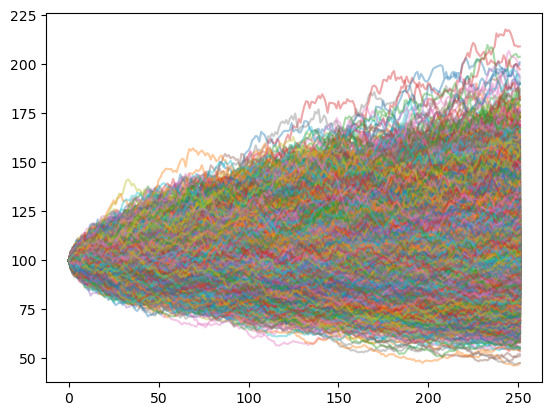

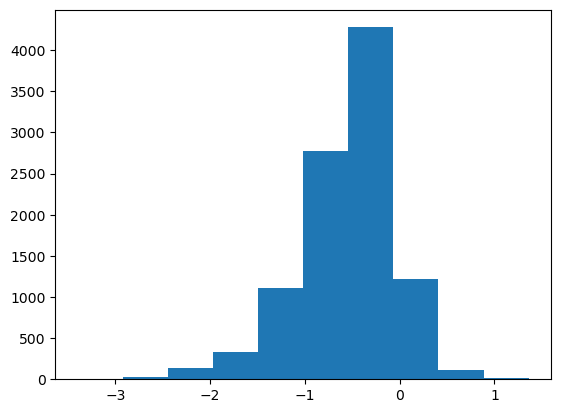

In [78]:
T = 1
n = 252
r = 0.03
fee_rate = 0.001

sim = PriceSimulator(100, 0.05, 0.2, T, n, 10_000, "GBM")
paths = sim.simulate()

greek = GreeksEngine("Call", 110, r, 0.2, 1)
premium = greek.price(100, 0)

t = np.linspace(0, T, n)
all_deltas = greek.compute_all_deltas(paths, t)
delta_diff = all_deltas[:, 1:] - all_deltas[:, :-1]
# prepend initial position change (from 0 to delta_0)
initial_diff = all_deltas[:, 0:1] # shape (m, 1)
delta_diff = np.hstack([initial_diff, delta_diff]) # shape (m, n)
cash_changes = -delta_diff * paths
cost = fee_rate * np.abs(delta_diff) * paths
cash_changes -= cost
time_remaining = T - t
total_cash = premium * np.exp(r * T) + (cash_changes * np.exp(r * time_remaining)).sum(axis=1)
payoff = np.maximum(paths[:, -1] - greek.K, 0)
final_PnL = total_cash + all_deltas[:, -1] * paths[:, -1] - payoff

# Plotting paths
plt.figure()
plt.plot(paths.T, alpha=0.4)
plt.show()

plt.figure()
plt.hist(final_PnL)
plt.show()

In [79]:
VaR_95 = -np.percentile(final_PnL, 5)
CVaR_95 = -final_PnL[final_PnL < -VaR_95].mean()
adjusted_premium = premium + CVaR_95

In [80]:
print("-" * 40)
print(f"final P&L mean: {final_PnL.mean()}")
print(f"final P&L SD: {final_PnL.std()}")
print(f"VaR 95%: {VaR_95}\nCVaR 95% = {CVaR_95}")
print(f"BS premium: {premium:.4f}\nCVaR-adjusted premium: {adjusted_premium:.4f}")
print("-" * 40)

----------------------------------------
final P&L mean: -0.5506125238108757
final P&L SD: 0.5145036227356697
VaR 95%: 1.4894809449791337
CVaR 95% = 1.88568129019312
BS premium: 5.2934
CVaR-adjusted premium: 7.1791
----------------------------------------


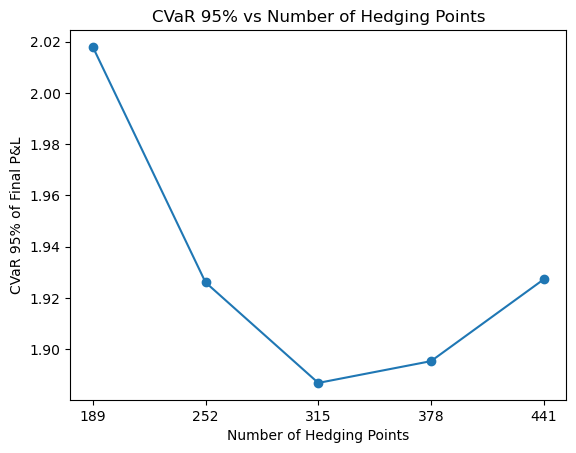

In [81]:
T = 1
r = 0.03
fee_rate = 0.001

n_items = [189, 252, 315, 378, 441]
CVaR_95_list = []

for n in n_items:
    sim = PriceSimulator(100, 0.05, 0.2, T, n, 10_000, "GBM")
    paths = sim.simulate()

    greek = GreeksEngine("Call", 110, r, 0.2, 1)
    premium = greek.price(100, 0)

    t = np.linspace(0, T, n)
    all_deltas = greek.compute_all_deltas(paths, t)
    delta_diff = all_deltas[:, 1:] - all_deltas[:, :-1]
    # prepend initial position change (from 0 to delta_0)
    initial_diff = all_deltas[:, 0:1] # shape (m, 1)
    delta_diff = np.hstack([initial_diff, delta_diff]) # shape (m, n)
    cash_changes = -delta_diff * paths
    cost = fee_rate * np.abs(delta_diff) * paths
    cash_changes -= cost
    time_remaining = T - t
    total_cash = premium * np.exp(r * T) + (cash_changes * np.exp(r * time_remaining)).sum(axis=1)
    payoff = np.maximum(paths[:, -1] - greek.K, 0)
    final_PnL = total_cash + all_deltas[:, -1] * paths[:, -1] - payoff

    VaR_95 = -np.percentile(final_PnL, 5)
    CVaR_95 = -final_PnL[final_PnL < -VaR_95].mean()

    CVaR_95_list.append(CVaR_95)

plt.plot(range(len(n_items)), CVaR_95_list, marker='o')
plt.xticks(range(len(n_items)), n_items)
plt.xlabel("Number of Hedging Points")
plt.ylabel("CVaR 95% of Final P&L")
plt.title("CVaR 95% vs Number of Hedging Points")
plt.show()